### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [24]:
df = pd.read_excel('dataset_final_project.xlsx', header=1)
df.head()

c:\Users\NelsonP\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,ARM,REF,DESCRICAO,TAMANHO,LOCALIZACAO,QUANTIDADE,PRECO MEDIO,PRECO3 IVA,TOTAL,COD MARCA,MARCA,FAMILIA,GRUPO,TIPO ARTIGO,COD SITUACAO,CAMPO USER2
0,1,0000188-ES14A,Placa para porta fatos - Poliestereno ES14 Azu...,UNI,NaN,1500,"0,08","0,07995",120,734,Wesley - Diversos,WESLEY DIVERSOS,DIVERSOS,NaN,HCAW22,NaN
1,1,0000234A,PORTA FATOS WESLEY - TNT80GMS 60X110,UNI,NaN,100,"3,1","7,503",310,734,Wesley - Diversos,WESLEY DIVERSOS,DIVERSOS,NaN,HCAW22,NaN
2,1,01224114AA,TECIDO LIBERTY: ROYAL BEE PICCADILY POPLIN COT...,UNI,NaN,5,"11,65","11,65056","58,25",734,Wesley - Diversos,TECIDO,NaN,NaN,TECS23,NaN
3,1,01224115CA,TECIDO LIBERTY: DARWINS VOYAGE PICCADILLY POPL...,UNI,NaN,5,"11,65","11,65056","58,25",734,Wesley - Diversos,TECIDO,NaN,NaN,TECS23,NaN
4,1,02351-298-MD,PAMPA OXFORD-PILAT,41,NaN,1,"19,52","74,9439","19,52",11,Palladium,CALÇADO HOMEM,PILAT,HOMEM,PS26,ICONICS


In [25]:
df.shape

(128075, 16)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128075 entries, 0 to 128074
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ARM           128075 non-null  int64  
 1   REF           128075 non-null  object 
 2   DESCRICAO     128075 non-null  object 
 3   TAMANHO       128070 non-null  object 
 4   LOCALIZACAO   75721 non-null   float64
 5   QUANTIDADE    128075 non-null  object 
 6   PRECO MEDIO   128075 non-null  object 
 7   PRECO3 IVA    128075 non-null  object 
 8   TOTAL         128075 non-null  object 
 9   COD MARCA     128075 non-null  int64  
 10  MARCA         128075 non-null  object 
 11  FAMILIA       127965 non-null  object 
 12  GRUPO         121274 non-null  object 
 13  TIPO ARTIGO   124988 non-null  object 
 14  COD SITUACAO  127469 non-null  object 
 15  CAMPO USER2   31405 non-null   object 
dtypes: float64(1), int64(2), object(13)
memory usage: 15.6+ MB


### Data Preparation

In [27]:
# Selecting useful columns for analysis

useful_columns = ['MARCA', 'ARM', 'REF', 'DESCRICAO', 'TAMANHO', 'LOCALIZACAO', 'QUANTIDADE', 'TIPO ARTIGO']
df_work = df[useful_columns].copy()
df_work.head()

,MARCA,ARM,REF,DESCRICAO,TAMANHO,LOCALIZACAO,QUANTIDADE,TIPO ARTIGO
0,Wesley - Diversos,1,0000188-ES14A,Placa para porta fatos - Poliestereno ES14 Azu...,UNI,NaN,1500,NaN
1,Wesley - Diversos,1,0000234A,PORTA FATOS WESLEY - TNT80GMS 60X110,UNI,NaN,100,NaN
2,Wesley - Diversos,1,01224114AA,TECIDO LIBERTY: ROYAL BEE PICCADILY POPLIN COT...,UNI,NaN,5,NaN
3,Wesley - Diversos,1,01224115CA,TECIDO LIBERTY: DARWINS VOYAGE PICCADILLY POPL...,UNI,NaN,5,NaN
4,Palladium,1,02351-298-MD,PAMPA OXFORD-PILAT,41,NaN,1,HOMEM


In [28]:
# Rename columns for english

df_work = df_work.rename(columns={
    'MARCA': 'BRAND',
    'ARM': 'WAREHOUSE',
    'REF': 'REFERENCE',
    'DESCRICAO': 'DESCRIPTION',
    'TAMANHO': 'SIZE',
    'LOCALIZACAO': 'LOCATION',
    'QUANTIDADE': 'QUANTITY',
    'TIPO ARTIGO': 'ITEM_TYPE'
})

df_work.head()

,BRAND,WAREHOUSE,REFERENCE,DESCRIPTION,SIZE,LOCATION,QUANTITY,ITEM_TYPE
0,Wesley - Diversos,1,0000188-ES14A,Placa para porta fatos - Poliestereno ES14 Azu...,UNI,NaN,1500,NaN
1,Wesley - Diversos,1,0000234A,PORTA FATOS WESLEY - TNT80GMS 60X110,UNI,NaN,100,NaN
2,Wesley - Diversos,1,01224114AA,TECIDO LIBERTY: ROYAL BEE PICCADILY POPLIN COT...,UNI,NaN,5,NaN
3,Wesley - Diversos,1,01224115CA,TECIDO LIBERTY: DARWINS VOYAGE PICCADILLY POPL...,UNI,NaN,5,NaN
4,Palladium,1,02351-298-MD,PAMPA OXFORD-PILAT,41,NaN,1,HOMEM


In [ ]:
# Check how many rows exist per warehouse 

df_work['WAREHOUSE'].value_counts().sort_index()


WAREHOUSE
1    36851
2    49436
3    13545
5    26285
6     1958
Name: count, dtype: int64

### Warehouse Filtering

The dataset contains multiple warehouse codes. For this project, only three are relevant:
- Warehouse 1: Central warehouse (sede) — stock source for replenishment
- Warehouse 2: Stores  — the core of the business
- Warehouse 5: Outlets - stores where we sell old stock or with discounts items

All other warehouse codes are excluded as out of scope for the replenishment logic.

In [ ]:
# Keep only the relevant warehouses: 

df_work = df_work[df_work['WAREHOUSE'].isin([1, 2, 5])].copy()

df_work['WAREHOUSE'].value_counts().sort_index()

WAREHOUSE
1    36851
2    49436
5    26285
Name: count, dtype: int64

In [39]:
df_work['LOCATION'].nunique()

38

In [41]:
df_work.groupby('WAREHOUSE')['LOCATION'].nunique()

WAREHOUSE
1     0
2    34
5     7
Name: LOCATION, dtype: int64

In [43]:
# Create a new column to identify the store or the warehouse

# Convert numeric locations to integer (removing the .0), keep 'HQ' as is
df_work['LOCATION'] = df_work['LOCATION'].apply(
    lambda x: str(int(x)) if x != 'HQ' else x
)

# Recreate the STORE_ID with clean location values
df_work['STORE_ID'] = df_work['WAREHOUSE'].astype(str) + '-' + df_work['LOCATION'].astype(str)

df_work['STORE_ID'].value_counts()

STORE_ID
1-HQ    36851
5-52     9398
5-53     6296
5-50     5491
2-14     5094
2-41     4369
2-8      3476
5-51     3454
2-12     3123
2-30     3025
2-40     2904
2-31     2571
2-11     2221
2-4      2061
2-3      1849
2-7      1657
5-54     1644
2-10     1589
2-1      1569
2-9      1544
2-2      1465
2-6      1323
2-94     1273
2-20     1170
2-91     1089
2-42     1023
2-22      955
2-92      820
2-96      800
2-24      754
2-90      618
2-97      489
2-98      383
2-85       82
2-80       68
2-82       37
2-13       30
2-54        3
2-51        1
2-21        1
5-20        1
5-43        1
Name: count, dtype: int64

In [46]:
df_work['QUANTITY'].unique()[:20]

array(['1500', '100', '5', '1', '6', '3', '11,3', '6,5', '2', '4', '51,9',
       '50,6', '18', '7', '13', '12', '-2', '8', '10', '9'], dtype=object)

In [47]:
# Portuguese number format uses comma as decimal separator — convert to proper float
df_work['QUANTITY'] = df_work['QUANTITY'].astype(str).str.replace(',', '.').astype(float)

df_work['QUANTITY'].dtype

dtype('float64')

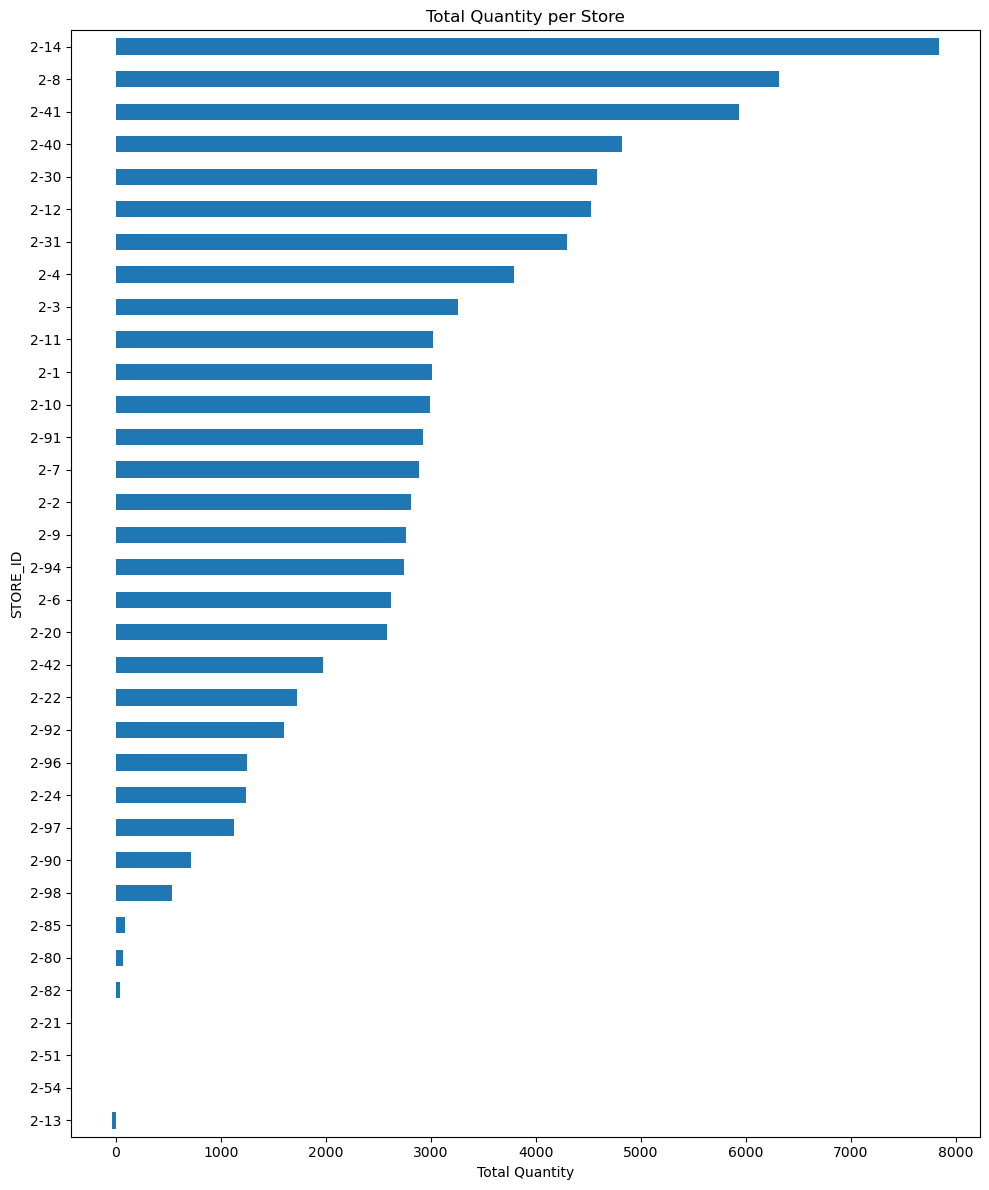

In [48]:
import matplotlib.pyplot as plt

store_quantity = df_work[df_work['WAREHOUSE'] == 2].groupby('STORE_ID')['QUANTITY'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 12))
store_quantity.plot(kind='barh')
plt.gca().invert_yaxis()  # highest values at the top
plt.xlabel('Total Quantity')
plt.title('Total Quantity per Store')
plt.tight_layout()
plt.show()